# Home Task:
1. Replicate `Simple Recommender` implementation
2. (Optional) Replicate `Content-Based Recommender` implementation

## Dataset
Download `movies_metadata.csv` from Kaggle:  
https://www.kaggle.com/rounakbanik/the-movies-dataset/data

# Simple Recommender

In [1]:
import pandas as pd
import numpy as np

# Load Movies Metadata
metadata = pd.read_csv('data/movies_metadata.csv', low_memory=False)

print('Dataset shape:', metadata.shape)
metadata.sample(3)

Dataset shape: (45466, 24)


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
42490,False,"{'id': 113589, 'name': 'The Hire', 'poster_pat...",0,"[{'id': 53, 'name': 'Thriller'}, {'id': 28, 'n...",http://bmwfilms.com/,417004,tt6078822,en,The Escape,After the controversial disappearance of their...,...,2016-10-23,0.0,13.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,So that one may live,The Escape,False,7.2,6.0
17890,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 28, 'name...",NaN,58402,tt0069818,it,Il boss,A bomb attack in a cinema in Palermo kills all...,...,1973-02-01,0.0,100.0,"[{'iso_639_1': 'it', 'name': 'Italiano'}]",Released,NaN,The Boss,False,6.6,9.0
39209,False,NaN,0,"[{'id': 80, 'name': 'Crime'}, {'id': 53, 'name...",NaN,31453,tt1290400,en,Double Identity,"In Chechnya, an American doctor takes a detour...",...,2009-12-18,0.0,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Double Identity,False,5.3,18.0


In [2]:
# small additional missing data check
percentage_missing = pd.DataFrame(metadata.isnull().sum() * 100 / len(metadata),
                                   columns=['percent_missing'])
percentage_missing.sort_values(by='percent_missing', ascending=False, inplace=True)

columns_with_missing_data = percentage_missing[percentage_missing['percent_missing'] > 0]
print(columns_with_missing_data)

                       percent_missing
belongs_to_collection        90.115691
homepage                     82.883913
tagline                      55.104914
overview                      2.098271
poster_path                   0.848986
runtime                       0.578454
status                        0.191352
release_date                  0.191352
imdb_id                       0.037391
original_language             0.024194
spoken_languages              0.013197
title                         0.013197
video                         0.013197
vote_average                  0.013197
revenue                       0.013197
vote_count                    0.013197
popularity                    0.010997
production_companies          0.006598
production_countries          0.006598


In [3]:
# Calculate C — mean vote average across all movies
C = metadata['vote_average'].mean()
print(C)

5.618207215134184


In [4]:
# Calculate m — 90th percentile of vote_count
m = metadata['vote_count'].quantile(0.90)
print(m)

160.0


In [5]:
# Filter to qualified movies (vote_count >= m)
q_movies = metadata.copy().loc[metadata['vote_count'] >= m]
print(f'Qualified movies:{q_movies.shape}')

Qualified movies:(4555, 24)


In [6]:
def weighted_rating(x, m=m, C=C):
    """
    Computes the IMDB-style weighted rating for a movie row

    v: number of votes for the movie
    m: minimum votes required
    R: average rating of the movie
    C: mean rating across all movies
    """
    v = x['vote_count']
    R = x['vote_average']
    return (v / (v + m) * R) + (m / (m + v) * C)

In [7]:
# Apply the function to compute the score for each qualified movie
q_movies['score'] = q_movies.apply(weighted_rating, axis=1)
q_movies[['title', 'vote_count', 'vote_average', 'score']].sample(5)

,title,vote_count,vote_average,score
4934,The Count of Monte Cristo,463.0,7.3,6.868079
33356,Wonder Woman,5025.0,7.2,7.151189
14926,Frozen,586.0,5.9,5.839562
6416,Seabiscuit,219.0,6.8,6.301090
3516,Moonraker,551.0,5.9,5.836587


In [8]:
# Sort by score descending and display Top 10
q_movies = q_movies.sort_values('score', ascending=False)
q_movies[['title', 'vote_count', 'vote_average', 'score']].head(10)

,title,vote_count,vote_average,score
314,The Shawshank Redemption,8358.0,8.5,8.445869
834,The Godfather,6024.0,8.5,8.425439
10309,Dilwale Dulhania Le Jayenge,661.0,9.1,8.421453
12481,The Dark Knight,12269.0,8.3,8.265477
2843,Fight Club,9678.0,8.3,8.256385
292,Pulp Fiction,8670.0,8.3,8.251406
522,Schindler's List,4436.0,8.3,8.206639
23673,Whiplash,4376.0,8.3,8.205404
5481,Spirited Away,3968.0,8.3,8.196055
2211,Life Is Beautiful,3643.0,8.3,8.187171


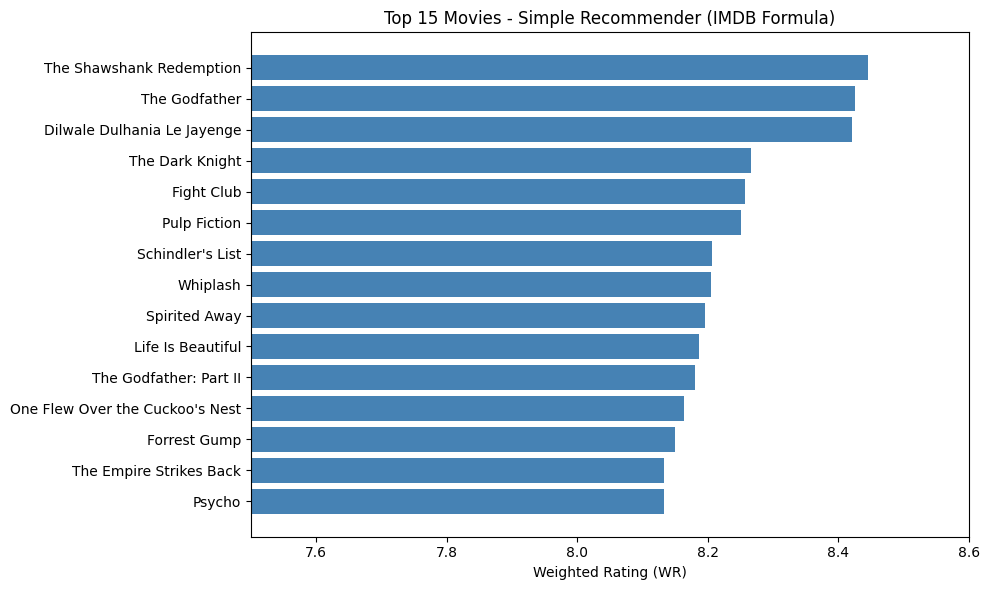

In [9]:
# Visualize the Top 15 movies
%matplotlib inline
import matplotlib.pyplot as plt

top15 = q_movies[['title', 'score']].head(15).iloc[::-1]  # reverse for horizontal bar

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top15['title'], top15['score'], color='steelblue')
ax.set_xlabel('Weighted Rating (WR)')
ax.set_title('Top 15 Movies - Simple Recommender (IMDB Formula)')
ax.set_xlim([7.5, 8.6]) # for better understanding
plt.tight_layout()
plt.show()


# (Optional): Content-Based Recommender


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

In [11]:
metadata = metadata.copy()

In [12]:
# Fill NaN overviews with empty string
metadata['overview'] = metadata['overview'].fillna('')

# Build TF-IDF matrix
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(metadata['overview'])

print('TF-IDF matrix shape:', tfidf_matrix.shape)

TF-IDF matrix shape: (45466, 75827)


In [13]:
# Compute cosine similarity matrix
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)
print('Cosine similarity matrix shape:', cosine_sim.shape)

Cosine similarity matrix shape: (45466, 45466)


In [14]:
# Build a reverse index: title -> DataFrame index
# This allows us to look up any movie by its title
indices = pd.Series(metadata.index, index=metadata['title']).drop_duplicates()
indices[:10]

title
Toy Story                      0
Jumanji                        1
Grumpier Old Men               2
Waiting to Exhale              3
Father of the Bride Part II    4
Heat                           5
Sabrina                        6
Tom and Huck                   7
Sudden Death                   8
GoldenEye                      9
dtype: int64

In [15]:
def get_recommendations(title, cosine_sim=cosine_sim, top_n=10):
    """
    Returns top-N movies most similar to title based on plot overview.
    """
    # Get the row index for this movie title
    idx = indices[title]
    # Get cosine similarity scores for this movie vs all others
    sim_scores = list(enumerate(cosine_sim[idx]))
    # Sort by similarity score (descending)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    # Skip the first entry (it's the movie itself, similarity = 1.0)
    sim_scores = sim_scores[1 : top_n + 1]
    # Retrieve movie indices from the sorted list
    movie_indices = [i[0] for i in sim_scores]
    # Retrieve similarity scores and round to 4 decimal places
    scores = [round(i[1], 4) for i in sim_scores]
    # in original return was a Series, modified it to DataFrame output
    result = pd.DataFrame({
        'title': metadata['title'].iloc[movie_indices].values,
        'cosine_similarity': scores
    })
    result.index = range(1, top_n + 1)
    return result

get_recommendations('Toy Story')

,title,cosine_similarity
1,Toy Story 3,0.5319
2,Toy Story 2,0.4720
3,The 40 Year Old Virgin,0.2750
4,Small Fry,0.2731
5,Andy Hardy's Blonde Trouble,0.2355
6,Hot Splash,0.2238
7,Andy Kaufman Plays Carnegie Hall,0.2177
8,Superstar: The Life and Times of Andy Warhol,0.2160
9,Andy Peters: Exclamation Mark Question Point,0.2020
10,The Champ,0.1988


In [16]:
# Test the recommender sys
get_recommendations('The Dark Knight Rises')

,title,cosine_similarity
1,The Dark Knight,0.3266
2,Batman Forever,0.3162
3,Batman Returns,0.2961
4,Batman: Under the Red Hood,0.2880
5,Batman,0.2707
6,Batman Unmasked: The Psychology of the Dark Kn...,0.2531
7,Batman Beyond: Return of the Joker,0.2344
8,Batman: Year One,0.2043
9,"Batman: The Dark Knight Returns, Part 1",0.1988
10,Batman: Mask of the Phantasm,0.1887


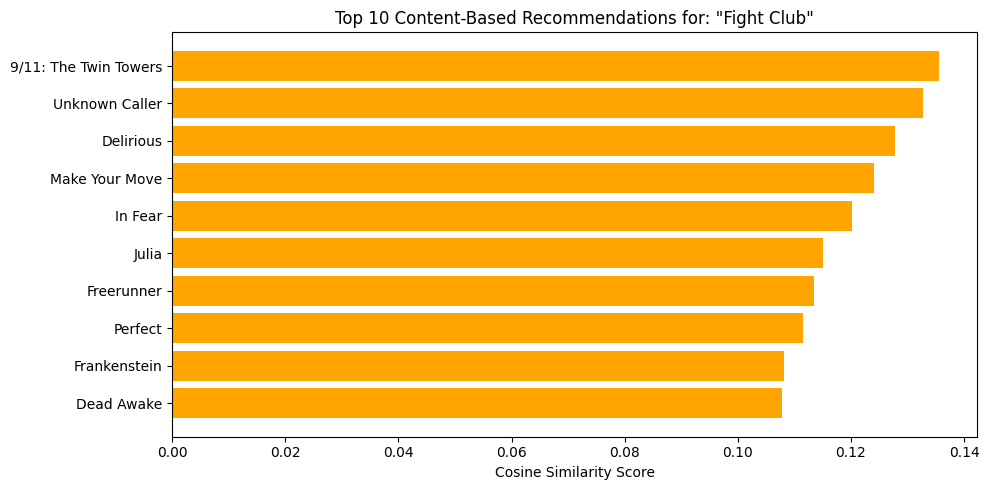

In [18]:
# Visualize cosine similarity scores for one movie's recommendations
target_movie = 'Fight Club'
rec = get_recommendations(target_movie).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(rec['title'], rec['cosine_similarity'], color='orange')
ax.set_xlabel('Cosine Similarity Score')
ax.set_title(f'Top 10 Content-Based Recommendations for: "{target_movie}"')
plt.tight_layout()
plt.show()